In [202]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [203]:
df = pd.read_csv("/content/diabetic_data.csv")

In [204]:
df


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [205]:
df.describe()


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [206]:
df.shape

(101766, 50)

In [207]:
df = df.drop_duplicates(subset=['patient_nbr'], keep='last')

In [208]:
df.shape

(71518, 50)

Replace ? with missing value


In [209]:
df = df.replace("?", np.nan)

In [210]:
df


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),NaN,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),NaN,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [211]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 71518 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   encounter_id              71518 non-null  int64 
 1   patient_nbr               71518 non-null  int64 
 2   race                      69640 non-null  object
 3   gender                    71518 non-null  object
 4   age                       71518 non-null  object
 5   weight                    2847 non-null   object
 6   admission_type_id         71518 non-null  int64 
 7   discharge_disposition_id  71518 non-null  int64 
 8   admission_source_id       71518 non-null  int64 
 9   time_in_hospital          71518 non-null  int64 
 10  payer_code                41433 non-null  object
 11  medical_specialty         36993 non-null  object
 12  num_lab_procedures        71518 non-null  int64 
 13  num_procedures            71518 non-null  int64 
 14  num_medications           

In [212]:
df.isna().sum()

,0
encounter_id,0
patient_nbr,0
race,1878
gender,0
age,0
weight,68671
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


# 4. Drop unnecessary columns

In [213]:
drops_cols =["encounter_id",
    "patient_nbr",
    "weight",
    "payer_code"]

In [214]:
df = df.drop(columns=drops_cols)

In [215]:
df


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,41,0,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),1,1,7,3,NaN,59,0,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),1,1,7,2,NaN,11,5,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),1,1,7,2,NaN,44,1,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),1,1,7,1,NaN,51,0,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,AfricanAmerican,Male,[70-80),1,3,7,3,NaN,51,0,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,AfricanAmerican,Female,[80-90),1,4,5,5,NaN,33,3,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,Caucasian,Male,[70-80),1,1,7,1,NaN,53,0,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,Caucasian,Female,[80-90),2,3,7,10,Surgery-General,45,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [216]:
df = df[df["gender"] != "Unknown/Invalid"]

In [217]:
df


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,41,0,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),1,1,7,3,NaN,59,0,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),1,1,7,2,NaN,11,5,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),1,1,7,2,NaN,44,1,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),1,1,7,1,NaN,51,0,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,AfricanAmerican,Male,[70-80),1,3,7,3,NaN,51,0,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,AfricanAmerican,Female,[80-90),1,4,5,5,NaN,33,3,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,Caucasian,Male,[70-80),1,1,7,1,NaN,53,0,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,Caucasian,Female,[80-90),2,3,7,10,Surgery-General,45,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [218]:
print(df["readmitted"].value_counts())

readmitted
NO     54371
>30    13920
<30     3224
Name: count, dtype: int64


In [219]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71515 entries, 0 to 101765
Data columns (total 46 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   race                      69639 non-null  object
 1   gender                    71515 non-null  object
 2   age                       71515 non-null  object
 3   admission_type_id         71515 non-null  int64 
 4   discharge_disposition_id  71515 non-null  int64 
 5   admission_source_id       71515 non-null  int64 
 6   time_in_hospital          71515 non-null  int64 
 7   medical_specialty         36992 non-null  object
 8   num_lab_procedures        71515 non-null  int64 
 9   num_procedures            71515 non-null  int64 
 10  num_medications           71515 non-null  int64 
 11  number_outpatient         71515 non-null  int64 
 12  number_emergency          71515 non-null  int64 
 13  number_inpatient          71515 non-null  int64 
 14  diag_1                    

In [220]:
df.isna().sum()

,0
race,1876
gender,0
age,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0
medical_specialty,34523
num_lab_procedures,0
num_procedures,0


In [221]:

df.drop(columns=['medical_specialty'])

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,AfricanAmerican,Male,[70-80),1,3,7,3,51,0,16,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,AfricanAmerican,Female,[80-90),1,4,5,5,33,3,18,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,Caucasian,Male,[70-80),1,1,7,1,53,0,9,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,Caucasian,Female,[80-90),2,3,7,10,45,2,21,...,No,Up,No,No,No,No,No,Ch,Yes,NO


medical_specialty

In [222]:
print(df["medical_specialty"])

0         Pediatrics-Endocrinology
1                              NaN
2                              NaN
3                              NaN
4                              NaN
                    ...           
101761                         NaN
101762                         NaN
101763                         NaN
101764             Surgery-General
101765                         NaN
Name: medical_specialty, Length: 71515, dtype: object


In [223]:
print(df["medical_specialty"].value_counts())

medical_specialty
InternalMedicine          11069
Family/GeneralPractice     5021
Emergency/Trauma           4463
Cardiology                 4142
Surgery-General            2235
                          ...  
Proctology                    1
Speech                        1
Perinatology                  1
Neurophysiology               1
Resident                      1
Name: count, Length: 69, dtype: int64


In [224]:
df = df.drop(columns=["medical_specialty"])

In [225]:
df.isna().sum()

,0
race,1876
gender,0
age,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0
num_lab_procedures,0
num_procedures,0
num_medications,0


In [226]:
df=df.drop(columns=['max_glu_serum'])

In [227]:
df.isna().sum()

,0
race,1876
gender,0
age,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0
num_lab_procedures,0
num_procedures,0
num_medications,0


In [228]:
print(df["A1Cresult"])

0         NaN
1         NaN
2         NaN
3         NaN
4         NaN
         ... 
101761     >8
101762    NaN
101763    NaN
101764    NaN
101765    NaN
Name: A1Cresult, Length: 71515, dtype: object


In [229]:
df['A1Cresult'] = df['A1Cresult'].replace('None', 'NotTested')
df['A1Cresult'] = df['A1Cresult'].fillna('NotTested')

In [230]:
df.isna().sum()

,0
race,1876
gender,0
age,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0
num_lab_procedures,0
num_procedures,0
num_medications,0


In [231]:
df=df.drop(columns=['race'])

In [232]:
df.isna().sum()

,0
gender,0
age,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0
num_lab_procedures,0
num_procedures,0
num_medications,0
number_outpatient,0


In [233]:
df=df.drop(columns=['gender'])

In [234]:
df.isna().sum()

,0
age,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0
num_lab_procedures,0
num_procedures,0
num_medications,0
number_outpatient,0
number_emergency,0


In [235]:
df = df.dropna(subset=['diag_1', 'diag_2', 'diag_3'])

In [236]:
df.isna().sum()

,0
age,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0
num_lab_procedures,0
num_procedures,0
num_medications,0
number_outpatient,0
number_emergency,0


# Readmission count

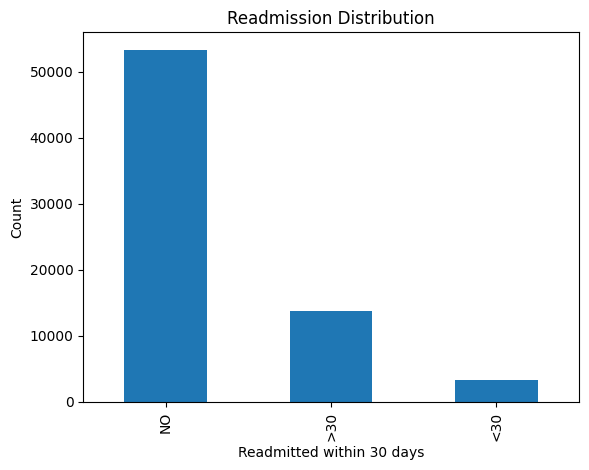

In [237]:
df["readmitted"].value_counts().plot(kind="bar")
plt.title("Readmission Distribution")
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Count")
plt.show()

In [238]:
print(df['readmitted'].value_counts())
print(df['readmitted'].value_counts(normalize=True)*100)

readmitted
NO     53330
>30    13774
<30     3201
Name: count, dtype: int64
readmitted
NO     75.855202
>30    19.591779
<30     4.553019
Name: proportion, dtype: float64


In [239]:
df['readmitted'] = df['readmitted'].replace({
    'NO': 0,
    '>30': 0,
    '<30': 1
})

/tmp/ipykernel_2433/3424438383.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['readmitted'] = df['readmitted'].replace({


In [240]:
print(df['readmitted'].value_counts())
print(df['readmitted'].value_counts(normalize=True)*100)

readmitted
0    67104
1     3201
Name: count, dtype: int64
readmitted
0    95.446981
1     4.553019
Name: proportion, dtype: float64


In [241]:
print(df["readmitted"].value_counts())

readmitted
0    67104
1     3201
Name: count, dtype: int64


In [242]:
print(df['readmitted'].value_counts())
print(df['readmitted'].value_counts(normalize=True)*100)

readmitted
0    67104
1     3201
Name: count, dtype: int64
readmitted
0    95.446981
1     4.553019
Name: proportion, dtype: float64


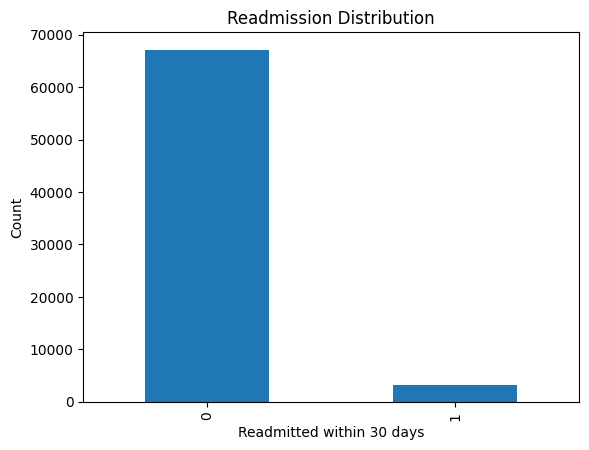

In [243]:
df["readmitted"].value_counts().plot(kind="bar")
plt.title("Readmission Distribution")
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Count")
plt.show()

 Age distribution


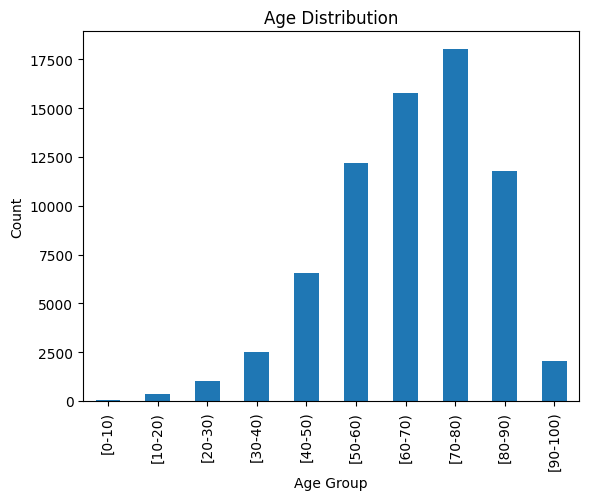

In [244]:
df["age"].value_counts().sort_index().plot(kind="bar")
plt.title("Age Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

In [245]:
age_map = {
    '[0-10)':5,
    '[10-20)':15,
    '[20-30)':25,
    '[30-40)':35,
    '[40-50)':45,
    '[50-60)':55,
    '[60-70)':65,
    '[70-80)':75,
    '[80-90)':85,
    '[90-100)':95
}

In [246]:
df['age'] = df['age'].map(age_map)

In [247]:
print(df['age'])

1         15
2         25
3         35
4         45
5         55
          ..
101761    75
101762    85
101763    75
101764    85
101765    75
Name: age, Length: 70305, dtype: int64


In [248]:
df

,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
1,15,1,1,7,3,59,0,18,0,0,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,25,1,1,7,2,11,5,13,2,0,...,No,No,No,No,No,No,No,No,Yes,0
3,35,1,1,7,2,44,1,16,0,0,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,45,1,1,7,1,51,0,8,0,0,...,No,Steady,No,No,No,No,No,Ch,Yes,0
5,55,2,1,2,3,31,6,16,0,0,...,No,Steady,No,No,No,No,No,No,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,75,1,3,7,3,51,0,16,0,0,...,No,Down,No,No,No,No,No,Ch,Yes,0
101762,85,1,4,5,5,33,3,18,0,0,...,No,Steady,No,No,No,No,No,No,Yes,0
101763,75,1,1,7,1,53,0,9,1,0,...,No,Down,No,No,No,No,No,Ch,Yes,0
101764,85,2,3,7,10,45,2,21,0,0,...,No,Up,No,No,No,No,No,Ch,Yes,0


# Time in hospital


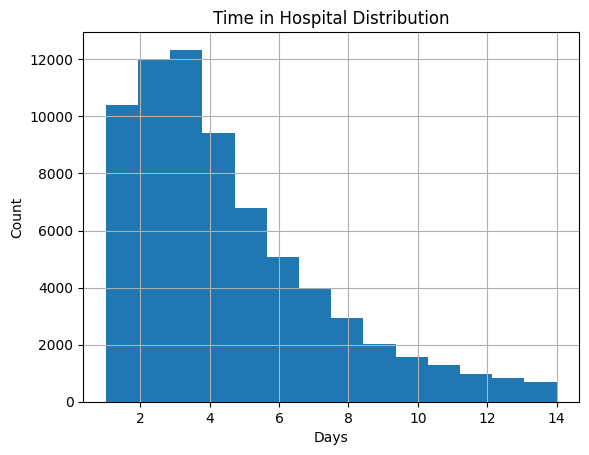

In [249]:
df["time_in_hospital"].hist(bins=14)
plt.title("Time in Hospital Distribution")
plt.xlabel("Days")
plt.ylabel("Count")
plt.show()

A1C result and readmission


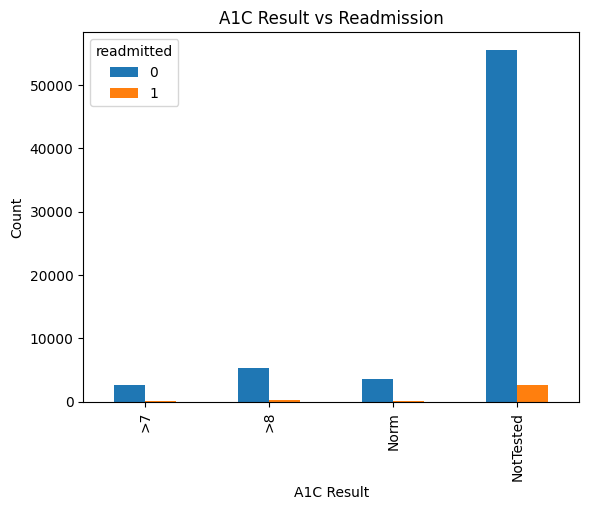

In [250]:
pd.crosstab(df["A1Cresult"], df["readmitted"]).plot(kind="bar")
plt.title("A1C Result vs Readmission")
plt.xlabel("A1C Result")
plt.ylabel("Count")
plt.show()

In [251]:
df

,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
1,15,1,1,7,3,59,0,18,0,0,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,25,1,1,7,2,11,5,13,2,0,...,No,No,No,No,No,No,No,No,Yes,0
3,35,1,1,7,2,44,1,16,0,0,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,45,1,1,7,1,51,0,8,0,0,...,No,Steady,No,No,No,No,No,Ch,Yes,0
5,55,2,1,2,3,31,6,16,0,0,...,No,Steady,No,No,No,No,No,No,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,75,1,3,7,3,51,0,16,0,0,...,No,Down,No,No,No,No,No,Ch,Yes,0
101762,85,1,4,5,5,33,3,18,0,0,...,No,Steady,No,No,No,No,No,No,Yes,0
101763,75,1,1,7,1,53,0,9,1,0,...,No,Down,No,No,No,No,No,Ch,Yes,0
101764,85,2,3,7,10,45,2,21,0,0,...,No,Up,No,No,No,No,No,Ch,Yes,0


In [252]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 70305 entries, 1 to 101765
Data columns (total 42 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   age                       70305 non-null  int64 
 1   admission_type_id         70305 non-null  int64 
 2   discharge_disposition_id  70305 non-null  int64 
 3   admission_source_id       70305 non-null  int64 
 4   time_in_hospital          70305 non-null  int64 
 5   num_lab_procedures        70305 non-null  int64 
 6   num_procedures            70305 non-null  int64 
 7   num_medications           70305 non-null  int64 
 8   number_outpatient         70305 non-null  int64 
 9   number_emergency          70305 non-null  int64 
 10  number_inpatient          70305 non-null  int64 
 11  diag_1                    70305 non-null  object
 12  diag_2                    70305 non-null  object
 13  diag_3                    70305 non-null  object
 14  number_diagnoses          

In [253]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].value_counts())


diag_1
diag_1
414       4927
428       4055
786       2905
410       2733
486       2393
          ... 
391          1
690          1
250.52       1
10           1
V51          1
Name: count, Length: 694, dtype: int64

diag_2
diag_2
276     4412
250     4384
428     4373
427     3487
401     2930
        ... 
V60        1
V55        1
843        1
E887       1
927        1
Name: count, Length: 710, dtype: int64

diag_3
diag_3
250     8730
401     6314
276     3549
428     2967
427     2728
        ... 
139        1
E966       1
123        1
971        1
565        1
Name: count, Length: 746, dtype: int64

A1Cresult
A1Cresult
NotTested    58265
>8            5590
Norm          3703
>7            2747
Name: count, dtype: int64

metformin
metformin
No        55966
Steady    13139
Up          779
Down        421
Name: count, dtype: int64

repaglinide
repaglinide
No        69341
Steady      853
Up           76
Down         35
Name: count, dtype: int64

nateglinide
nateglinide
No        698

In [254]:
print(df['examide'].value_counts())

examide
No    70305
Name: count, dtype: int64


Examide Column


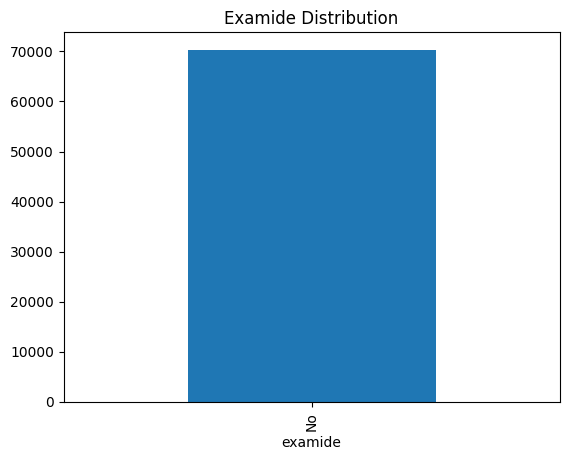

In [255]:
import matplotlib.pyplot as plt

df['examide'].value_counts().plot(kind='bar')

plt.title('Examide Distribution')
plt.show()

In [256]:
print(df['citoglipton'].value_counts())

citoglipton
No    70305
Name: count, dtype: int64


Citoglipton column

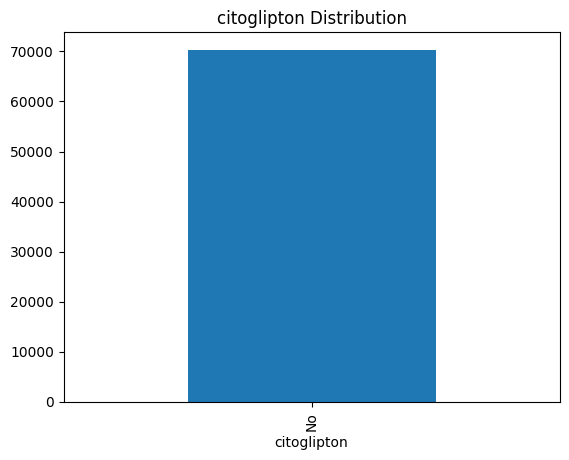

In [257]:
import matplotlib.pyplot as plt

df['citoglipton'].value_counts().plot(kind='bar')

plt.title('citoglipton Distribution')
plt.show()

glimepiride-pioglitazone Column

In [258]:
print(df['glimepiride-pioglitazone'].value_counts())

glimepiride-pioglitazone
No    70305
Name: count, dtype: int64


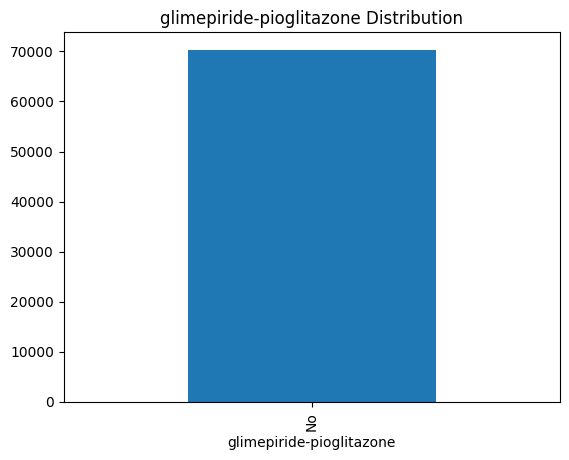

In [259]:
import matplotlib.pyplot as plt

df['glimepiride-pioglitazone'].value_counts().plot(kind='bar')

plt.title('glimepiride-pioglitazone Distribution')
plt.show()

In [260]:
print(df['acetohexamide'].value_counts())

acetohexamide
No        70304
Steady        1
Name: count, dtype: int64


In [261]:
df.shape

(70305, 42)

**These columns contain almost no information because nearly every value is the same.**

In [262]:
drop_cols = [
    'examide',
    'citoglipton',
    'glimepiride-pioglitazone',
    'acetohexamide',
    'troglitazone',
    'metformin-pioglitazone',
    'metformin-rosiglitazone',
    'glipizide-metformin'
]


In [263]:

df=df.drop(columns=drop_cols)

In [264]:
df.shape

(70305, 34)

In [265]:
for col in drop_cols:
    print(col in df.columns)

False
False
False
False
False
False
False
False


**Encoding**

In [266]:
cat_cols = df.select_dtypes(include='object').columns

print(cat_cols)

Index(['diag_1', 'diag_2', 'diag_3', 'A1Cresult', 'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide',
       'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
       'miglitol', 'tolazamide', 'insulin', 'glyburide-metformin', 'change',
       'diabetesMed'],
      dtype='object')


In [267]:
cat_cols.shape

(21,)

**Encode Medication Columns**

In [268]:
mapping = {
    'No':0,
    'Steady':1,
    'Up':2,
    'Down':3
}

med_cols = [
    'metformin','repaglinide','nateglinide',
    'chlorpropamide','glimepiride',
    'glipizide','glyburide',
    'tolbutamide','pioglitazone',
    'rosiglitazone','acarbose',
    'miglitol','tolazamide',
    'insulin','glyburide-metformin'
]

for col in med_cols:
    df[col] = df[col].map(mapping)

In [269]:
med_cols

['metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'tolazamide',
 'insulin',
 'glyburide-metformin']

In [270]:
df

,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,...,pioglitazone,rosiglitazone,acarbose,miglitol,tolazamide,insulin,glyburide-metformin,change,diabetesMed,readmitted
1,15,1,1,7,3,59,0,18,0,0,...,0,0,0,0,0,2,0,Ch,Yes,0
2,25,1,1,7,2,11,5,13,2,0,...,0,0,0,0,0,0,0,No,Yes,0
3,35,1,1,7,2,44,1,16,0,0,...,0,0,0,0,0,2,0,Ch,Yes,0
4,45,1,1,7,1,51,0,8,0,0,...,0,0,0,0,0,1,0,Ch,Yes,0
5,55,2,1,2,3,31,6,16,0,0,...,0,0,0,0,0,1,0,No,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,75,1,3,7,3,51,0,16,0,0,...,0,0,0,0,0,3,0,Ch,Yes,0
101762,85,1,4,5,5,33,3,18,0,0,...,0,0,0,0,0,1,0,No,Yes,0
101763,75,1,1,7,1,53,0,9,1,0,...,0,0,0,0,0,3,0,Ch,Yes,0
101764,85,2,3,7,10,45,2,21,0,0,...,1,0,0,0,0,2,0,Ch,Yes,0


In [271]:
df['A1Cresult'] = df['A1Cresult'].map({
    'NotTested':0,
    'Norm':1,
    '>7':2,
    '>8':3
})

In [272]:
print(df['A1Cresult'])

1         0
2         0
3         0
4         0
5         0
         ..
101761    3
101762    0
101763    0
101764    0
101765    0
Name: A1Cresult, Length: 70305, dtype: int64


 Split features and target

**Encode Change**

In [273]:
df['change'] = df['change'].map({
    'No':0,
    'Ch':1
})

In [274]:
print(df['change'])

1         1
2         0
3         1
4         1
5         0
         ..
101761    1
101762    0
101763    1
101764    1
101765    0
Name: change, Length: 70305, dtype: int64


**Encode DiabetesMed**

In [275]:
df['diabetesMed'] = df['diabetesMed'].map({
    'No':0,
    'Yes':1
})

In [276]:
print(df['diabetesMed'])

1         1
2         1
3         1
4         1
5         1
         ..
101761    1
101762    1
101763    1
101764    1
101765    0
Name: diabetesMed, Length: 70305, dtype: int64


**Encode Diagnosis Columns**

In [277]:
from sklearn.preprocessing import LabelEncoder

for col in ['diag_1','diag_2','diag_3']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

**Create Useful Features**

In [278]:
df['total_visits'] = (
    df['number_outpatient']
    + df['number_emergency']
    + df['number_inpatient']
)

df['meds_per_day'] = (
    df['num_medications']
    / df['time_in_hospital']
)

In [279]:
print(df.dtypes)

age                           int64
admission_type_id             int64
discharge_disposition_id      int64
admission_source_id           int64
time_in_hospital              int64
num_lab_procedures            int64
num_procedures                int64
num_medications               int64
number_outpatient             int64
number_emergency              int64
number_inpatient              int64
diag_1                        int64
diag_2                        int64
diag_3                        int64
number_diagnoses              int64
A1Cresult                     int64
metformin                     int64
repaglinide                   int64
nateglinide                   int64
chlorpropamide                int64
glimepiride                   int64
glipizide                     int64
glyburide                     int64
tolbutamide                   int64
pioglitazone                  int64
rosiglitazone                 int64
acarbose                      int64
miglitol                    

In [280]:
df.shape


(70305, 36)

In [281]:
df

,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,...,acarbose,miglitol,tolazamide,insulin,glyburide-metformin,change,diabetesMed,readmitted,total_visits,meds_per_day
1,15,1,1,7,3,59,0,18,0,0,...,0,0,0,2,0,1,1,0,0,6.000000
2,25,1,1,7,2,11,5,13,2,0,...,0,0,0,0,0,0,1,0,3,6.500000
3,35,1,1,7,2,44,1,16,0,0,...,0,0,0,2,0,1,1,0,0,8.000000
4,45,1,1,7,1,51,0,8,0,0,...,0,0,0,1,0,1,1,0,0,8.000000
5,55,2,1,2,3,31,6,16,0,0,...,0,0,0,1,0,0,1,0,0,5.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,75,1,3,7,3,51,0,16,0,0,...,0,0,0,3,0,1,1,0,0,5.333333
101762,85,1,4,5,5,33,3,18,0,0,...,0,0,0,1,0,0,1,0,1,3.600000
101763,75,1,1,7,1,53,0,9,1,0,...,0,0,0,3,0,1,1,0,1,9.000000
101764,85,2,3,7,10,45,2,21,0,0,...,0,0,0,2,0,1,1,0,1,2.100000


In [282]:
print(df.shape)

(70305, 36)


In [283]:
print(df.dtypes.unique())

[dtype('int64') dtype('float64')]


**shuffle all rows randomly**

In [284]:
df = df.sample(frac=1, random_state=100).reset_index(drop=True)

In [285]:
df

,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,...,acarbose,miglitol,tolazamide,insulin,glyburide-metformin,change,diabetesMed,readmitted,total_visits,meds_per_day
0,45,1,1,7,7,36,0,29,0,0,...,0,0,0,3,0,1,1,0,1,4.142857
1,75,1,6,7,1,45,2,8,0,0,...,0,0,0,0,0,0,0,0,0,8.000000
2,55,1,6,7,7,59,0,17,0,0,...,0,0,0,0,0,0,1,0,2,2.428571
3,65,3,2,4,7,49,1,15,0,0,...,0,0,0,0,0,0,0,0,2,2.142857
4,55,1,1,7,4,28,1,10,0,0,...,0,0,0,0,0,0,1,0,0,2.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70300,75,1,1,7,4,39,4,13,0,0,...,0,0,0,0,0,0,0,0,2,3.250000
70301,85,1,3,7,5,71,4,21,0,0,...,0,0,0,0,0,1,1,0,0,4.200000
70302,75,1,2,7,4,54,0,18,0,0,...,0,0,0,0,0,0,1,0,0,4.500000
70303,95,6,3,7,3,45,0,14,0,0,...,0,0,0,0,0,0,0,0,1,4.666667


**Train/Test split**

In [286]:
X = df.drop('readmitted', axis=1)
y = df['readmitted']

In [287]:

X.shape

(70305, 35)

In [288]:
y.shape

(70305,)

**Apply SMOTE to Balance Classes**

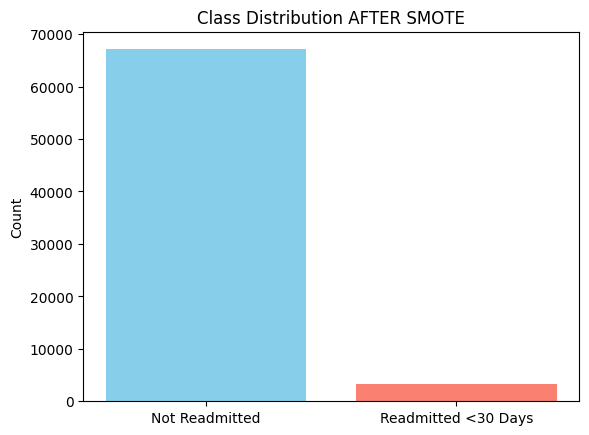

In [289]:
plt.bar(
    y.value_counts().index,
    y.value_counts().values,
    color=['skyblue', 'salmon']
)

plt.xticks([0, 1], ['Not Readmitted', 'Readmitted <30 Days'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE")
plt.show()

readmitted
0    53683
1    53683
Name: count, dtype: int64


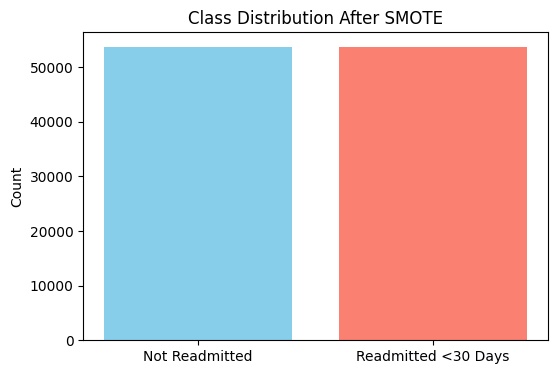

In [290]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt



# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Apply SMOTE ONLY on training data
smote = SMOTE(
    sampling_strategy='minority',
    random_state=42
)

X_train_sm, y_train_sm = smote.fit_resample(
    X_train,
    y_train
)

# Check class distribution after SMOTE
print(y_train_sm.value_counts())

# Plot
plt.figure(figsize=(6,4))

plt.bar(
    y_train_sm.value_counts().index,
    y_train_sm.value_counts().values,
    color=['skyblue', 'salmon']
)

plt.xticks(
    [0, 1],
    ['Not Readmitted', 'Readmitted <30 Days']
)

plt.ylabel("Count")
plt.title("Class Distribution After SMOTE")

plt.show()

In [291]:

y_train_sm.shape

(107366,)

In [292]:
X_train_sm.shape

(107366, 35)

**  Machine Learning Models**

**1. Logistic Regression**

In [293]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_sm, y_train_sm)

y_pred_lr = lr.predict(X_test)

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.96      0.71      0.81     13421
           1       0.05      0.34      0.09       640

    accuracy                           0.69     14061
   macro avg       0.50      0.52      0.45     14061
weighted avg       0.92      0.69      0.78     14061



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**2. Random Forest**

In [294]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     13421
           1       0.10      0.05      0.07       640

    accuracy                           0.93     14061
   macro avg       0.53      0.51      0.52     14061
weighted avg       0.92      0.93      0.93     14061



**3. XGBoost**

In [295]:
pip install xgboost

In [296]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train_sm, y_train_sm)

y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     13421
           1       0.12      0.06      0.08       640

    accuracy                           0.94     14061
   macro avg       0.54      0.52      0.53     14061
weighted avg       0.92      0.94      0.93     14061



In [297]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

print(importance.head(20))

                     Feature  Importance
0                        age    0.177939
16                 metformin    0.084038
3        admission_source_id    0.071381
2   discharge_disposition_id    0.047585
25             rosiglitazone    0.047387
31                    change    0.043090
21                 glipizide    0.037296
24              pioglitazone    0.036923
22                 glyburide    0.036785
14          number_diagnoses    0.035182
29                   insulin    0.032335
15                 A1Cresult    0.028698
33              total_visits    0.027712
20               glimepiride    0.027666
1          admission_type_id    0.025495
8          number_outpatient    0.024703
10          number_inpatient    0.021845
6             num_procedures    0.020521
32               diabetesMed    0.020436
34              meds_per_day    0.018461


In [298]:
y_prob = xgb.predict_proba(X_test)[:,1]

y_pred = (y_prob >= 0.50).astype(int)

In [299]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     13421
           1       0.12      0.06      0.08       640

    accuracy                           0.94     14061
   macro avg       0.54      0.52      0.53     14061
weighted avg       0.92      0.94      0.93     14061



In [300]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [301]:
from sklearn.metrics import classification_report

y_pred = xgb.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.83      0.89     13421
           1       0.09      0.36      0.14       640

    accuracy                           0.81     14061
   macro avg       0.53      0.59      0.52     14061
weighted avg       0.92      0.81      0.86     14061



In [302]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Calculate class imbalance ratio
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

# Train XGBoost
xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

# Predictions
y_pred = xgb.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.83      0.89     13421
           1       0.09      0.36      0.14       640

    accuracy                           0.81     14061
   macro avg       0.53      0.59      0.52     14061
weighted avg       0.92      0.81      0.86     14061

Accuracy: 0.8062015503875969
[[11107  2314]
 [  411   229]]


In [303]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Calculate class imbalance ratio
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

# Train XGBoost
xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

# Predictions
y_pred = xgb.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.83      0.89     13421
           1       0.09      0.36      0.14       640

    accuracy                           0.81     14061
   macro avg       0.53      0.59      0.52     14061
weighted avg       0.92      0.81      0.86     14061

Accuracy: 0.8062015503875969
[[11107  2314]
 [  411   229]]


Instead of SMOTE Trying SMOTEENN

In [304]:
from imblearn.combine import SMOTEENN

In [305]:
from sklearn.model_selection import train_test_split

X = df.drop('readmitted', axis=1)
y = df['readmitted']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [306]:
from imblearn.combine import SMOTEENN

smoteenn = SMOTEENN(random_state=42)

X_train_se, y_train_se = smoteenn.fit_resample(
    X_train,
    y_train
)

print(y_train_se.value_counts())

readmitted
1    52318
0    38843
Name: count, dtype: int64


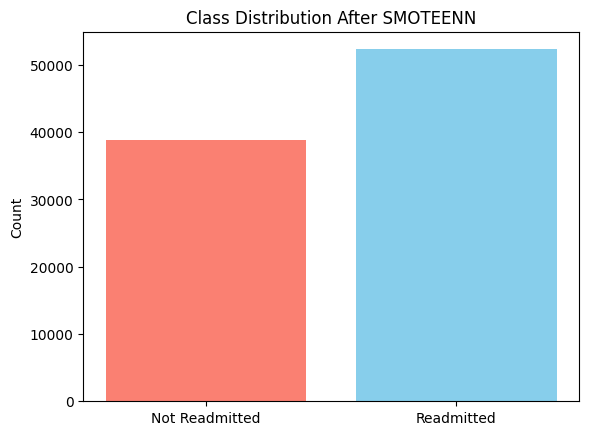

In [307]:
import matplotlib.pyplot as plt

plt.bar(
    y_train_se.value_counts().index,
    y_train_se.value_counts().values,
    color=['skyblue', 'salmon']
)

plt.xticks(
    [0,1],
    ['Not Readmitted', 'Readmitted']
)

plt.ylabel("Count")
plt.title("Class Distribution After SMOTEENN")

plt.show()

In [308]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train_se, y_train_se)

y_pred = xgb.predict(X_test)

In [309]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96     13421
           1       0.12      0.12      0.12       640

    accuracy                           0.92     14061
   macro avg       0.54      0.54      0.54     14061
weighted avg       0.92      0.92      0.92     14061

